# Fetch the data

In [5]:
!pip install opendatasets --quiet
import opendatasets as od
od.download('https://www.kaggle.com/datasets/andrewmvd/animal-faces')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tsepomayaba
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:03<00:00, 211MB/s]


# Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

from PIL import Image
import os
from time import time

# Enable the GPU

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Import the data

In [8]:
try:
  start_time = time()

  # Root directory containing the images
  folder_path = '/content/animal-faces/afhq'

  # Data structure to store the images
  images = []

  # Data structure to store the target/label
  labels = []

  # Iteration
  for i in os.listdir(folder_path):
    for label in os.listdir(f'{folder_path}/{i}'):
      for image in os.listdir(f'{folder_path}/{i}/{label}'):
        images.append(f'{folder_path}/{i}/{label}/{image}')
        labels.append(label)

  df = pd.DataFrame(zip(images, labels), columns=['image_path', 'label'])

  print('Data loading completed!\n')

except Exception as e:
  print(f'Error while loading the data: {e}')

finally:
  end_time = time()
  total_time = end_time - start_time

  print(f'Total time taken: {round(total_time, 4)}s')

Data loading completed!

Total time taken: 0.0187s


# Data Preprocessing
This dataset does not need much preprocessing steps (thanks to the Kaggle user <i>Larxel</i> for this!)

#### 1. Convert the categorical data into numeric
One thing about computers is that they do not understand text but only numbers. Therefore, any text data need to be converted into a number.

In [9]:
# Initialize the LabelEncoder object
le = LabelEncoder()

# Fit the object
le.fit(df['label'])

# Make the images have the same props
ts = transforms.Compose([
    transforms.Resize((128,128)), # width x height
    transforms.ToTensor(), # convert from np.array -> tensore
    transforms.ConvertImageDtype(torch.float)
])
ts

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    ConvertImageDtype()
)

#### 2. Data Partitioning
In this section, we will be splitting the dataset into **Training**, **Testing** and **Validation** datasets using a custom splitting algorithm instead of the train_test_split algorithm from sklearn.

In [10]:
# create a custom dataset
class dataset(Dataset):
  def __init__(self, df, transform=None):
    self.df = df
    self.transform = transform
    self.labels = torch.tensor(
        le.transform(df['label'])
    ).to(device)

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    # Get the image path at a specific index
    img_url = self.df.iloc[idx, 0]

    # Get the labels
    label = self.labels[idx]

    # Open the image
    image = Image.open(img_url).convert('RGB')

    # Check if transform has been provided
    if self.transform:

      # Transform the image
      image = self.transform(image).to(device)

    return image, label

In [11]:
# 70% of dataset is used for training
train_df = df.sample(frac=0.7)

# 30% of dataset is used for testing
test_df = df.drop(train_df.index)

# 15% of the testing dataset will be the Validation dataset
val_df = test_df.sample(frac=0.5)

# Now the Testing dataset will be 15%
test_df.drop(val_df.index, inplace=True)

print(f'Training dataset dimensions: {train_df.shape}')
print(f'Testing dataset dimensions: {test_df.shape}')
print(f'Validation dataset dimensions: {val_df.shape}')

Training dataset dimensions: (11291, 2)
Testing dataset dimensions: (2419, 2)
Validation dataset dimensions: (2420, 2)


In [12]:
processed_train_df = dataset(df = train_df, transform=ts)
print(f'Length of processed training data: {processed_train_df.__len__()}')

processed_test_df = dataset(df = test_df, transform=ts)
print(f'Length of processed testing data: {processed_test_df.__len__()}')

processed_val_df = dataset(df = val_df, transform=ts)
print(f'Length of processed validation data: {processed_val_df.__len__()}')

Length of processed training data: 11291
Length of processed testing data: 2419
Length of processed validation data: 2420


#### 3. Plotting
We will create a plot that randomly selects and displays 9 different animals from the dataset. This plot shows the preprocessing applied to the image.

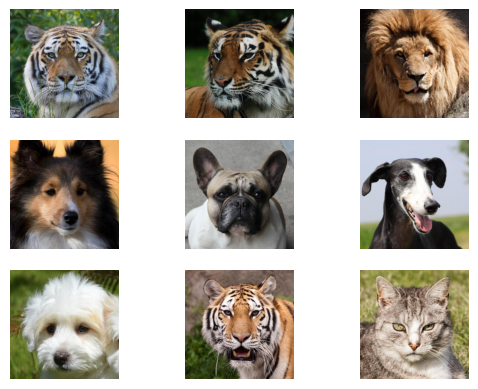

In [13]:
fig, axs = plt.subplots(nrows=3, ncols=3)

for row in range(3):
  for col in range(3):
    # Open a random image
    image = Image.open(df.sample(n=1)['image_path'].iloc[0]).convert('RGB')
    axs[row, col].imshow(image)
    axs[row, col].axis('off')
plt.show()

# Model Development
In this section, we will begin to setup the Convolutional Neural Network and then begin training.

#### 1. Setup the data loaders

In [14]:
# CONSTANTS
LR = 1e-4
BATCH_SIZE=16
EPOCHS = 10 # Small epoch due to resource constraints

# Create data loaders
train_data_loader = DataLoader(processed_train_df, BATCH_SIZE, shuffle=True)
test_data_loader = DataLoader(processed_test_df, BATCH_SIZE, shuffle=True)
val_data_loader = DataLoader(processed_val_df, BATCH_SIZE, shuffle=True)


#### 2. Create the model

In [15]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # Create the layers
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 channels -> R G B
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    # Create the pooling area
    self.pooling = nn.MaxPool2d(2,2)

    # Activation Function (optional but recommended)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()

    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(df['label'].unique()))


  def forward(self, X):
    """This function defines how the data flows"""
    X = self.conv1(X) # Convolution increases the number of features while keeping the image properties the same
    X = self.pooling(X) # Pooling modifies the image properties while keeping the number of features the same
    X = self.relu(X)

    X = self.conv2(X)
    X = self.pooling(X)
    X = self.relu(X)

    X = self.conv3(X)
    X = self.pooling(X)
    X = self.relu(X)

    X = self.flatten(X)
    X = self.linear(X)
    X = self.output(X)
    return X


In [16]:
# Initialize the CNN model
model = Model().to(device)

# Summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

#### 3. Define the loss and optimizer

In [17]:
# Define the loss
criterion = nn.CrossEntropyLoss() # loss for multiclass classification

# Define optimizer
optimizer = Adam(model.parameters(), lr=LR)

#### 4. Setup the training loop

In [18]:
# Data structure to store the loss after each epoch during training
total_training_loss = []
total_validation_loss = []

total_training_acc = []
total_validation_acc = []

for epoch in range(EPOCHS):
  # Variables
  total_train_loss = 0
  total_val_loss = 0
  total_train_acc = 0
  total_val_acc = 0

  for inputs, labels in train_data_loader:
    # Reset the optimizer
    optimizer.zero_grad()

    # Pass inputs to the model
    preds = model(inputs)

    # Calcluate the loss
    train_loss = criterion(preds, labels)

    # Update the total loss of the epoch during training
    total_train_loss += train_loss.item()

    # Backward propagation
    train_loss.backward()

    # Calculate the accuracy - 3 outputs, 3 possiblities
    train_acc = (torch.argmax(preds, axis=1) == labels).sum().item()

    # Update the total accuracy for the epoch
    total_train_acc += train_acc

    # Optimize the weights
    optimizer.step()

  # use model without optimizer
  with torch.no_grad():
    for inputs, labels in val_data_loader:
      # Generate predictions
      preds = model(inputs)

      # Calculate the loss
      val_loss = criterion(preds, labels)

      # Update the loss for the validation
      total_val_loss += val_loss.item()

      # Calculate the validation accuracy
      val_acc = (torch.argmax(preds, axis=1) == labels).sum().item()
      total_val_acc += val_acc

  total_training_loss.append(round(total_train_loss/1000, 4))
  total_validation_loss.append(round(total_val_loss/1000, 4))

  total_training_acc.append(round(total_train_acc/processed_train_df.__len__() * 100, 4))
  total_validation_acc.append(round(total_val_acc/processed_val_df.__len__() * 100, 4))

  print(f'''
    Epoch {epoch+1}/{EPOCHS}
    Train loss: {round(total_train_loss/1000, 4)}
    Train accuracy: {round(total_train_acc/processed_train_df.__len__() * 100, 4)}
    Validation loss: {round(total_val_loss/1000, 4)}
    Validation accuracy: {round(total_val_acc/processed_val_df.__len__() * 100, 4)}
  ''')


    Epoch 1/10 
    Train loss: 0.3222
    Train accuracy: 81.3745
    Validation loss: 0.0374
    Validation accuracy: 91.1983
  

    Epoch 2/10 
    Train loss: 0.1395
    Train accuracy: 92.8439
    Validation loss: 0.0221
    Validation accuracy: 94.4215
  

    Epoch 3/10 
    Train loss: 0.0867
    Train accuracy: 95.5363
    Validation loss: 0.0193
    Validation accuracy: 95.7438
  

    Epoch 4/10 
    Train loss: 0.0637
    Train accuracy: 96.7408
    Validation loss: 0.0165
    Validation accuracy: 96.3636
  

    Epoch 5/10 
    Train loss: 0.0484
    Train accuracy: 97.5113
    Validation loss: 0.0174
    Validation accuracy: 95.9504
  

    Epoch 6/10 
    Train loss: 0.0373
    Train accuracy: 98.0693
    Validation loss: 0.014
    Validation accuracy: 96.9008
  

    Epoch 7/10 
    Train loss: 0.0266
    Train accuracy: 98.7778
    Validation loss: 0.0176
    Validation accuracy: 96.1983
  

    Epoch 8/10 
    Train loss: 0.0222
    Train accuracy: 98.9195
    Valid

# Model Evaluation
In this section, we will be evaluating the performance of the model to generalize on unseen data.

In [19]:
with torch.no_grad():
  total_test_loss = 0
  total_test_acc = 0
  for inputs, labels in test_data_loader:
    # Generate predictions
    preds = model(inputs)

    # Calculate the accuracy
    acc = (torch.argmax(preds, axis=1) == labels).sum().item()
    total_test_acc += acc

    # Calculate the loss
    test_loss = criterion(preds, labels)
    total_test_loss += test_loss.item()

print(f'Accuracy score: {round(total_test_acc/processed_test_df.__len__() * 100, 4)}% | Loss: {round(total_test_loss/1000, 4)}')



Accuracy score: 95.6594% | Loss: 0.0238


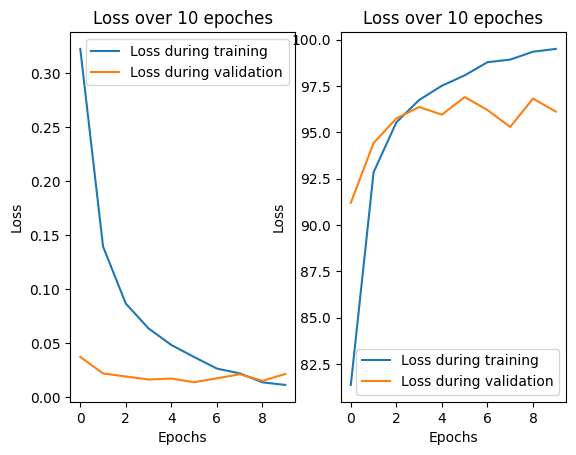

In [ ]:
# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2)

axs[0].plot(total_training_loss, label='Loss during training')
axs[0].plot(total_validation_loss, label='Loss during validation')
axs[0].set_title(f'Loss over {EPOCHS} epoches')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()


axs[1].plot(total_training_acc, label='Accuracy during training')
axs[1].plot(total_validation_acc, label='Accuracy during validation')
axs[1].set_title(f'Loss over {EPOCHS} epoches')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()

plt.show()

# Results
The model performed very good during training but has failed to generalize to new unseen data. This is a sign of **overfitting**. It possibly means that our model is overly complex or the data is noisy.

---

# Further improvements

- Get more images to train the model
- Reduce the number of features/layers to simplify the model
- Add a Dropout layer to penalize the model if it is overly complex